# Inspect Top Losses Across Steps

Loads `loss_trigger_analysis_step_<step>_valid.json` reports for a run, then summarizes:
- top batch mean loss
- top batch max token loss
- top event loss

You can select reports by explicit step list or by `NUM_STEPS` most recent available steps.


In [1]:
import json
import re
from dataclasses import dataclass

import pandas as pd
import matplotlib.pyplot as plt
from etils import epath
from IPython.display import display


In [2]:
# ---- User config ----
BUCKET = "gs://demand-v4-checkpoint-storage"
RUN_NAME = "glowing-moon-136"
SPLIT = "valid"  # usually valid
NUM_STEPS = 10    # used when STEP_LIST is None
STEP_LIST = [1000, 1042, 1043, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1166]  # e.g., [1000, 1020, 1040]

BASE_DIR = epath.Path(f"{BUCKET.rstrip('/')}/{RUN_NAME}/evaluation_metrics")
print("BASE_DIR:", BASE_DIR)


BASE_DIR: gs://demand-v4-checkpoint-storage/glowing-moon-136/evaluation_metrics


In [3]:
step_pat = re.compile(r"step_(\d+)$")

all_step_dirs = []
for p in BASE_DIR.iterdir():
    m = step_pat.search(p.name)
    if m:
        all_step_dirs.append((int(m.group(1)), p))

all_step_dirs = sorted(all_step_dirs, key=lambda x: x[0])
all_steps = [s for s, _ in all_step_dirs]
print(f"Found {len(all_steps)} step dirs")
if all_steps:
    print("min step:", all_steps[0], "max step:", all_steps[-1])


Found 15 step dirs
min step: 1000 max step: 1166


In [4]:
if STEP_LIST is not None:
    selected_steps = sorted(int(s) for s in STEP_LIST)
else:
    selected_steps = all_steps[-int(NUM_STEPS):]

print("Selected steps:", selected_steps)


Selected steps: [1000, 1042, 1043, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1166]


In [7]:
records = []
missing = []

for step in selected_steps:
    report_path = BASE_DIR / f"step_{step}" / f"loss_trigger_analysis_step_{step}_{SPLIT}.json"
    if not report_path.exists():
        missing.append(str(report_path))
        continue

    with report_path.open('r') as f:
        rep = json.load(f)

    top_batches = rep.get('top_batches_by_mean_loss', [])
    top_events = rep.get('top_token_events', [])

    top_batch = top_batches[0] if top_batches else {}
    top_event = top_events[0] if top_events else {}

    rec = {
        'step': int(step),
        'top_batch_index': top_batch.get('batch_index'),
        'top_batch_mean_loss': top_batch.get('mean_loss'),
        'top_batch_max_token_loss': top_batch.get('max_token_loss'),
        'top_event_loss': top_event.get('loss'),
        'next_train_batch_max_token_loss': (rep.get('next_train_batch_analysis') or {}).get('batch_max_token_loss'),
        'top_event_batch_index': top_event.get('batch_index'),
        'top_event_example_index': top_event.get('example_index'),
        'top_event_position': top_event.get('position'),
        'top_event_input_token_id': top_event.get('input_token_id'),
        'top_event_target_token_id': top_event.get('target_token_id'),
        'top_event_context_text': top_event.get('context_text'),
        'report_path': str(report_path),
    }
    records.append(rec)

if missing:
    print(f"Missing {len(missing)} reports:")
    for p in missing[:20]:
        print("  ", p)
    if len(missing) > 20:
        print("  ...")

df = pd.DataFrame(records).sort_values('step').reset_index(drop=True)
print("Loaded reports:", len(df))
display(df)


Loaded reports: 13


,step,top_batch_index,top_batch_mean_loss,top_batch_max_token_loss,top_event_loss,next_train_batch_max_token_loss,top_event_batch_index,top_event_example_index,top_event_position,top_event_input_token_id,top_event_target_token_id,top_event_context_text,report_path
0,1000,51,6.105184,51.038719,71.458275,50.898430,39,171,0,3644,991,computer,gs://demand-v4-checkpoint-storage/glowing-moon...
1,1042,44,6.122414,53.758289,64.516045,51.561646,33,138,592,18137,442,chocolate truffles.\nRum milk chocolate truff...,gs://demand-v4-checkpoint-storage/glowing-moon...
2,1043,46,6.128188,52.104221,76.652580,53.869774,9,222,236,15376,3664,- 1 egg\n- ½ tsp. baking powder\n- ½ tsp. baki...,gs://demand-v4-checkpoint-storage/glowing-moon...
3,1044,46,6.152328,52.939457,164.000580,53.873516,68,149,21,3365,20012,2021-03-02 15:36:522021-03-02 15:36:58,gs://demand-v4-checkpoint-storage/glowing-moon...
4,1045,44,6.209176,114.156113,228.750000,74.477791,62,4,1,1959,24065,-29,gs://demand-v4-checkpoint-storage/glowing-moon...
5,1046,44,6.200148,139.750046,426.500336,133.943253,46,8,562,19,33341,", placed again during junior campaign\nAll-Ame...",gs://demand-v4-checkpoint-storage/glowing-moon...
6,1047,44,6.179508,148.054047,368.018158,49.767223,20,107,266,15363,1592,games during January.\nPrince pitched in 22 p...,gs://demand-v4-checkpoint-storage/glowing-moon...
7,1048,44,6.217526,79.213852,352.326874,229.501358,42,191,2,17,24754,7.2,gs://demand-v4-checkpoint-storage/glowing-moon...
8,1049,44,7.694522,298.500000,908.000000,724.002502,47,227,692,1448,40731,"appetite:\nTim Etchells is, quite frankly, a ...",gs://demand-v4-checkpoint-storage/glowing-moon...
9,1050,35,42.371979,144.950500,610.000000,153.361801,31,116,14,9455,1924,the commencement of the 50 th Commemoration o...,gs://demand-v4-checkpoint-storage/glowing-moon...


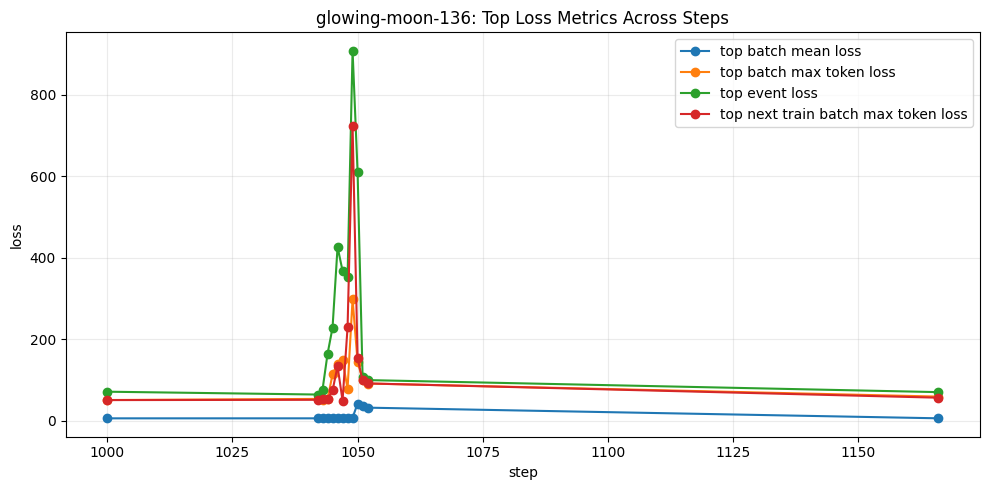

In [9]:
if len(df):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df['step'], df['top_batch_mean_loss'], marker='o', label='top batch mean loss')
    ax.plot(df['step'], df['top_batch_max_token_loss'], marker='o', label='top batch max token loss')
    ax.plot(df['step'], df['top_event_loss'], marker='o', label='top event loss')
    ax.plot(df['step'], df['next_train_batch_max_token_loss'], marker='o', label='top next train batch max token loss')
    ax.set_title(f"{RUN_NAME}: Top Loss Metrics Across Steps")
    ax.set_xlabel('step')
    ax.set_ylabel('loss')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [15]:
# Print concise per-step summary
for _, r in df.iterrows():
    print(
        f"step={int(r.step):<6} top_batch_mean={r.top_batch_mean_loss:.6f} "
        f"top_batch_max_token={r.top_batch_max_token_loss:.6f} top_event={r.top_event_loss:.6f} top_train_batch_max_token={r.next_train_batch_max_token_loss:.6f}"
    )


step=1000   top_batch_mean=6.105184 top_batch_max_token=51.038719 top_event=71.458275 top_train_batch_max_token=50.898430
step=1042   top_batch_mean=6.122414 top_batch_max_token=53.758289 top_event=64.516045 top_train_batch_max_token=51.561646
step=1043   top_batch_mean=6.128188 top_batch_max_token=52.104221 top_event=76.652580 top_train_batch_max_token=53.869774
step=1044   top_batch_mean=6.152328 top_batch_max_token=52.939457 top_event=164.000580 top_train_batch_max_token=53.873516
step=1045   top_batch_mean=6.209176 top_batch_max_token=114.156113 top_event=228.750000 top_train_batch_max_token=74.477791
step=1046   top_batch_mean=6.200148 top_batch_max_token=139.750046 top_event=426.500336 top_train_batch_max_token=133.943253
step=1047   top_batch_mean=6.179508 top_batch_max_token=148.054047 top_event=368.018158 top_train_batch_max_token=49.767223
step=1048   top_batch_mean=6.217526 top_batch_max_token=79.213852 top_event=352.326874 top_train_batch_max_token=229.501358
step=1049   to

In [12]:
# Robust threshold tuning from across-step loss series (proxy for online gating).
# This uses top_event_loss as a conservative proxy for tail behavior.

series_name = 'top_event_loss'  # change to 'top_batch_max_token_loss' if you prefer
s = df[series_name].dropna().astype(float)

if len(s) < 5:
    print(f'Not enough points in {series_name} to tune thresholds.')
else:
    med = float(s.median())
    mad = float((s - med).abs().median())
    scale = max(1.4826 * mad, 1e-9)
    robust_z = (s - med) / scale

    tune_df = pd.DataFrame({
        'step': df.loc[s.index, 'step'].values,
        series_name: s.values,
        'robust_z': robust_z.values,
    })
    print(f'{series_name}: median={med:.6f}, MAD={mad:.6f}, scaled_MAD={scale:.6f}')
    display(tune_df)


top_event_loss: median=164.000580, MAD=93.598473, scaled_MAD=138.769095


,step,top_event_loss,robust_z
0,1000,71.458275,-0.666880
1,1042,64.516045,-0.716907
2,1043,76.652580,-0.629449
3,1044,164.000580,0.000000
4,1045,228.750000,0.466598
5,1046,426.500336,1.891630
6,1047,368.018158,1.470195
7,1048,352.326874,1.357120
8,1049,908.000000,5.361420
9,1050,610.000000,3.213968


In [13]:
# Sweep candidate z_hard values (hard skip rate proxy)
if len(s) >= 5:
    z_hard_grid = [4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
    rows = []
    for zh in z_hard_grid:
        hard_rate = float((robust_z > zh).mean())
        rows.append({'z_hard': zh, 'hard_skip_rate_proxy': hard_rate})
    hard_df = pd.DataFrame(rows)
    display(hard_df)


,z_hard,hard_skip_rate_proxy
0,4.0,0.076923
1,5.0,0.076923
2,6.0,0.000000
3,7.0,0.000000
4,8.0,0.000000
5,9.0,0.000000
6,10.0,0.000000


In [9]:
# Optional: inspect top event context for each step
cols = ['step', 'top_event_context_text']
if len(df):
    display(df[cols])


,step,top_event_context_text
0,1000,computer
1,1048,7.2
2,1049,"appetite:\nTim Etchells is, quite frankly, a ..."
3,1050,the commencement of the 50 th Commemoration o...
4,1051,it
5,1052,\nTo keep up with the latest news and special ...
6,1166,GA Championship at Oak Hill was remarkable for...
